# Unified Photometry

In [1]:
import warnings
warnings.filterwarnings("ignore")
from astropy.table import Table, Column, vstack
from astropy.coordinates import SkyCoord
from astropy.time import Time
from astropy.io import fits
import astropy.units as u
import numpy as np
import pandas as pd
from utils import *
from catalog import *
from photometry import *
from subtraction import *
from photutils.psf import IterativePSFPhotometry
ra, dec = 149.9025,	-3.3073
# ra, dec = 149.9134113, -3.3085028
# ra, dec = 149.9015318, -3.3201282
band = 'i'

In [2]:
fits_dir = '/Volumes/T7/Shared_Files/EP/Results/Follow_up/optical_data/EP260131a/SOAR/cutout/EP260131a_20260227_stack_i_wcs.fits.fits'
fpath = '/Volumes/T7/Shared_Files/EP/Results/Follow_up/optical_data/EP260131a/SOAR/cutout'
cat_dir = '/Volumes/T7/Shared_Files/EP/Results/Follow_up/optical_data/EP260131a/ps.csv'

In [3]:
phot = Photometry()
phot.read_image(fits_dir,masklow=None)

Image and WCS loaded successfully.


In [5]:
# zp_res = phot.compute_zeropoint(cat_dir=cat_dir,path=fpath,mag_col=band,mag_cut=16,fwhm=6,threshold_sigma=3.0)

In [6]:
# 'Check ZP Fitting and you can apply magnitude cut (mag_cut) to exclude bright srats'
# import matplotlib.pyplot as plt
# zp_values = zp_res['zp_values']
# pesu_x = zp_res['mag']

# fig, ax = plt.subplots(figsize=(7,3),dpi=100)
# ax.scatter(pesu_x, zp_values, label='ZP values')
# ax.plot(pesu_x, np.full_like(pesu_x, zp_res['zeropoint']), color='red', label='ZP fit')
# ax.fill_between(np.linspace(15,24),zp_res['zeropoint'] - zp_res['zp_std'], zp_res['zeropoint'] + zp_res['zp_std'], color='red', alpha=0.2)
# ax.set_xlabel('Mag')
# ax.set_ylabel('ZP')

Matched stars before filtering: 45
After saturation filtering: 45

Zeropoint = 31.864 ± 0.046  (N=33)


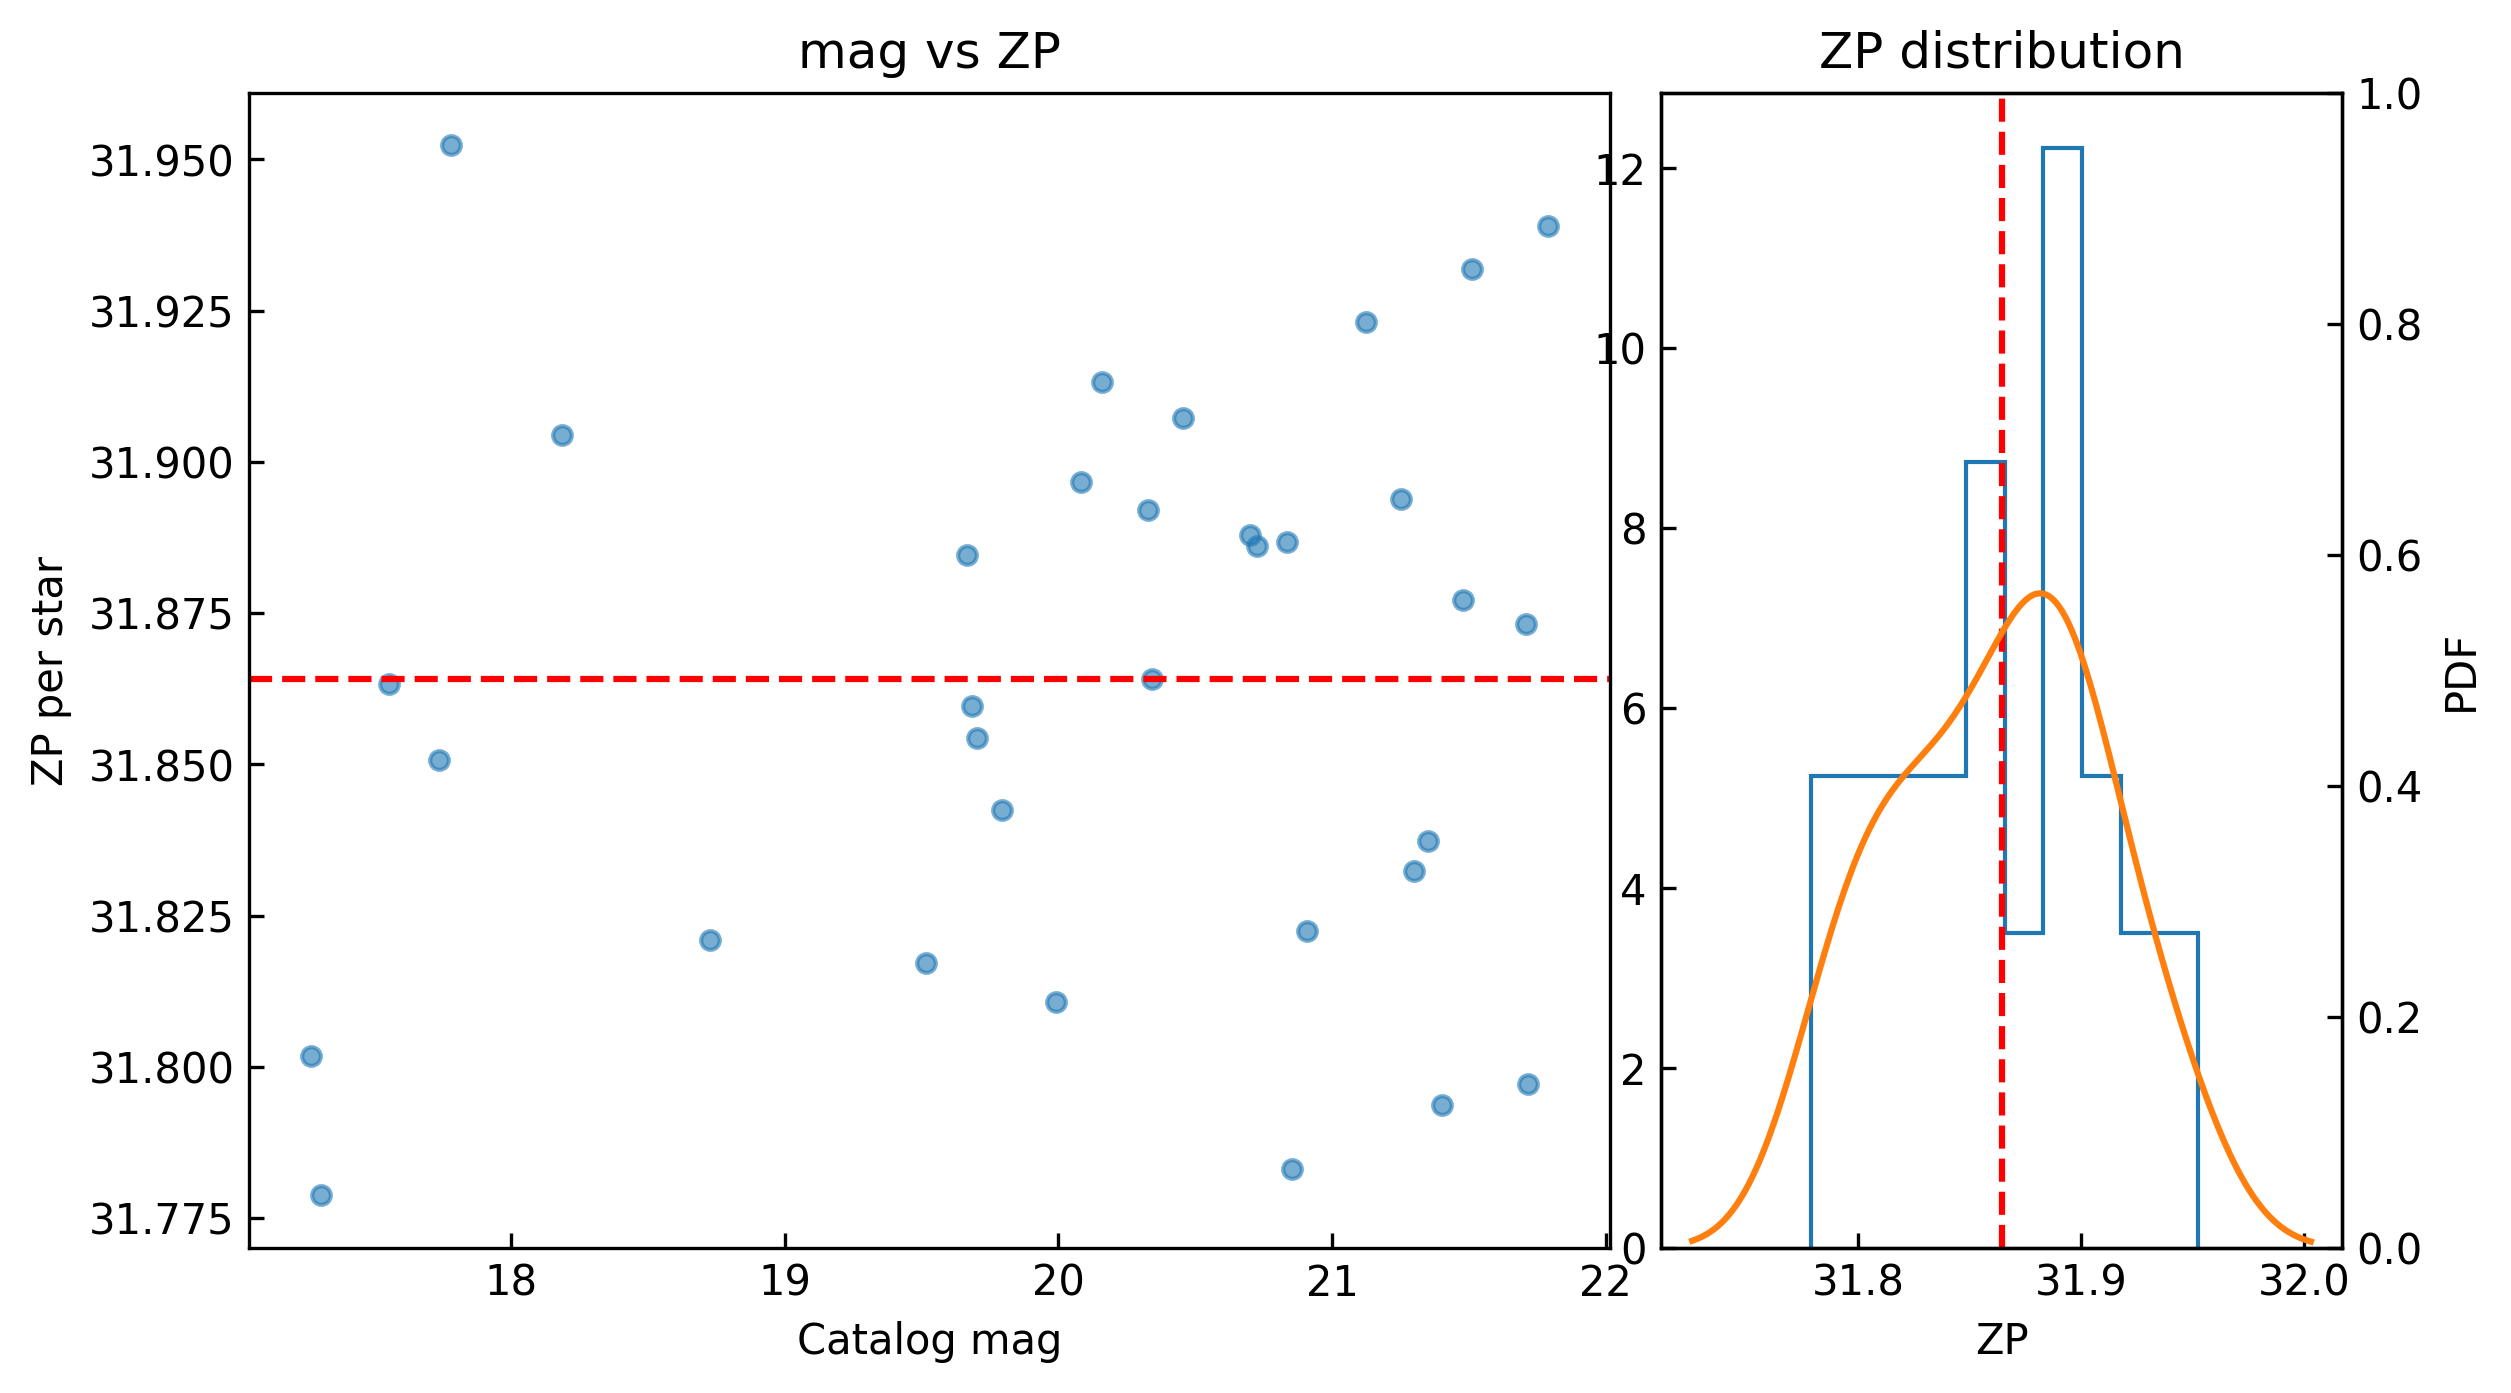

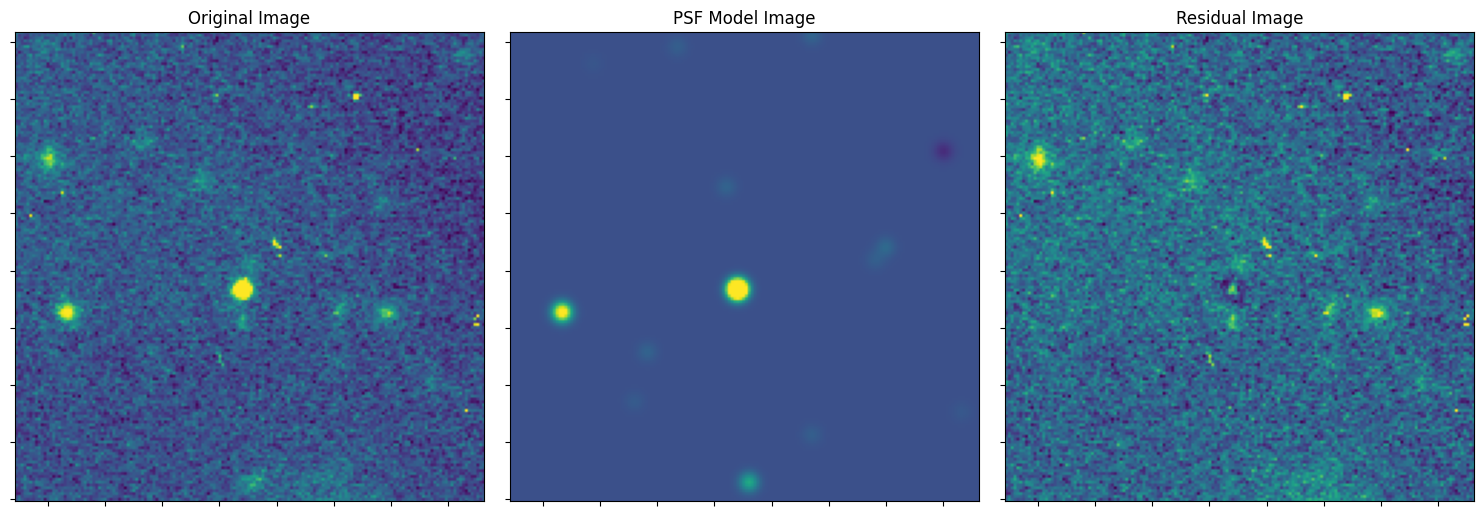

Target not detected → computing upper limit
3-sigma upper limit = 24.149


{'upper_limit': 24.149305209144245}

In [4]:
'PSF Photometry after ZP calibration'

res = phot.psf_photometry(ra=ra,dec=dec,fwhm=5.5,sigma=3.,sigma_clip_val=2.0,cat_dir=cat_dir,mag_col=band,fit_shape=(9,9),forced=False,)
res

Matched stars before filtering: 45
After saturation filtering: 45

Zeropoint = 31.864 ± 0.046  (N=33)


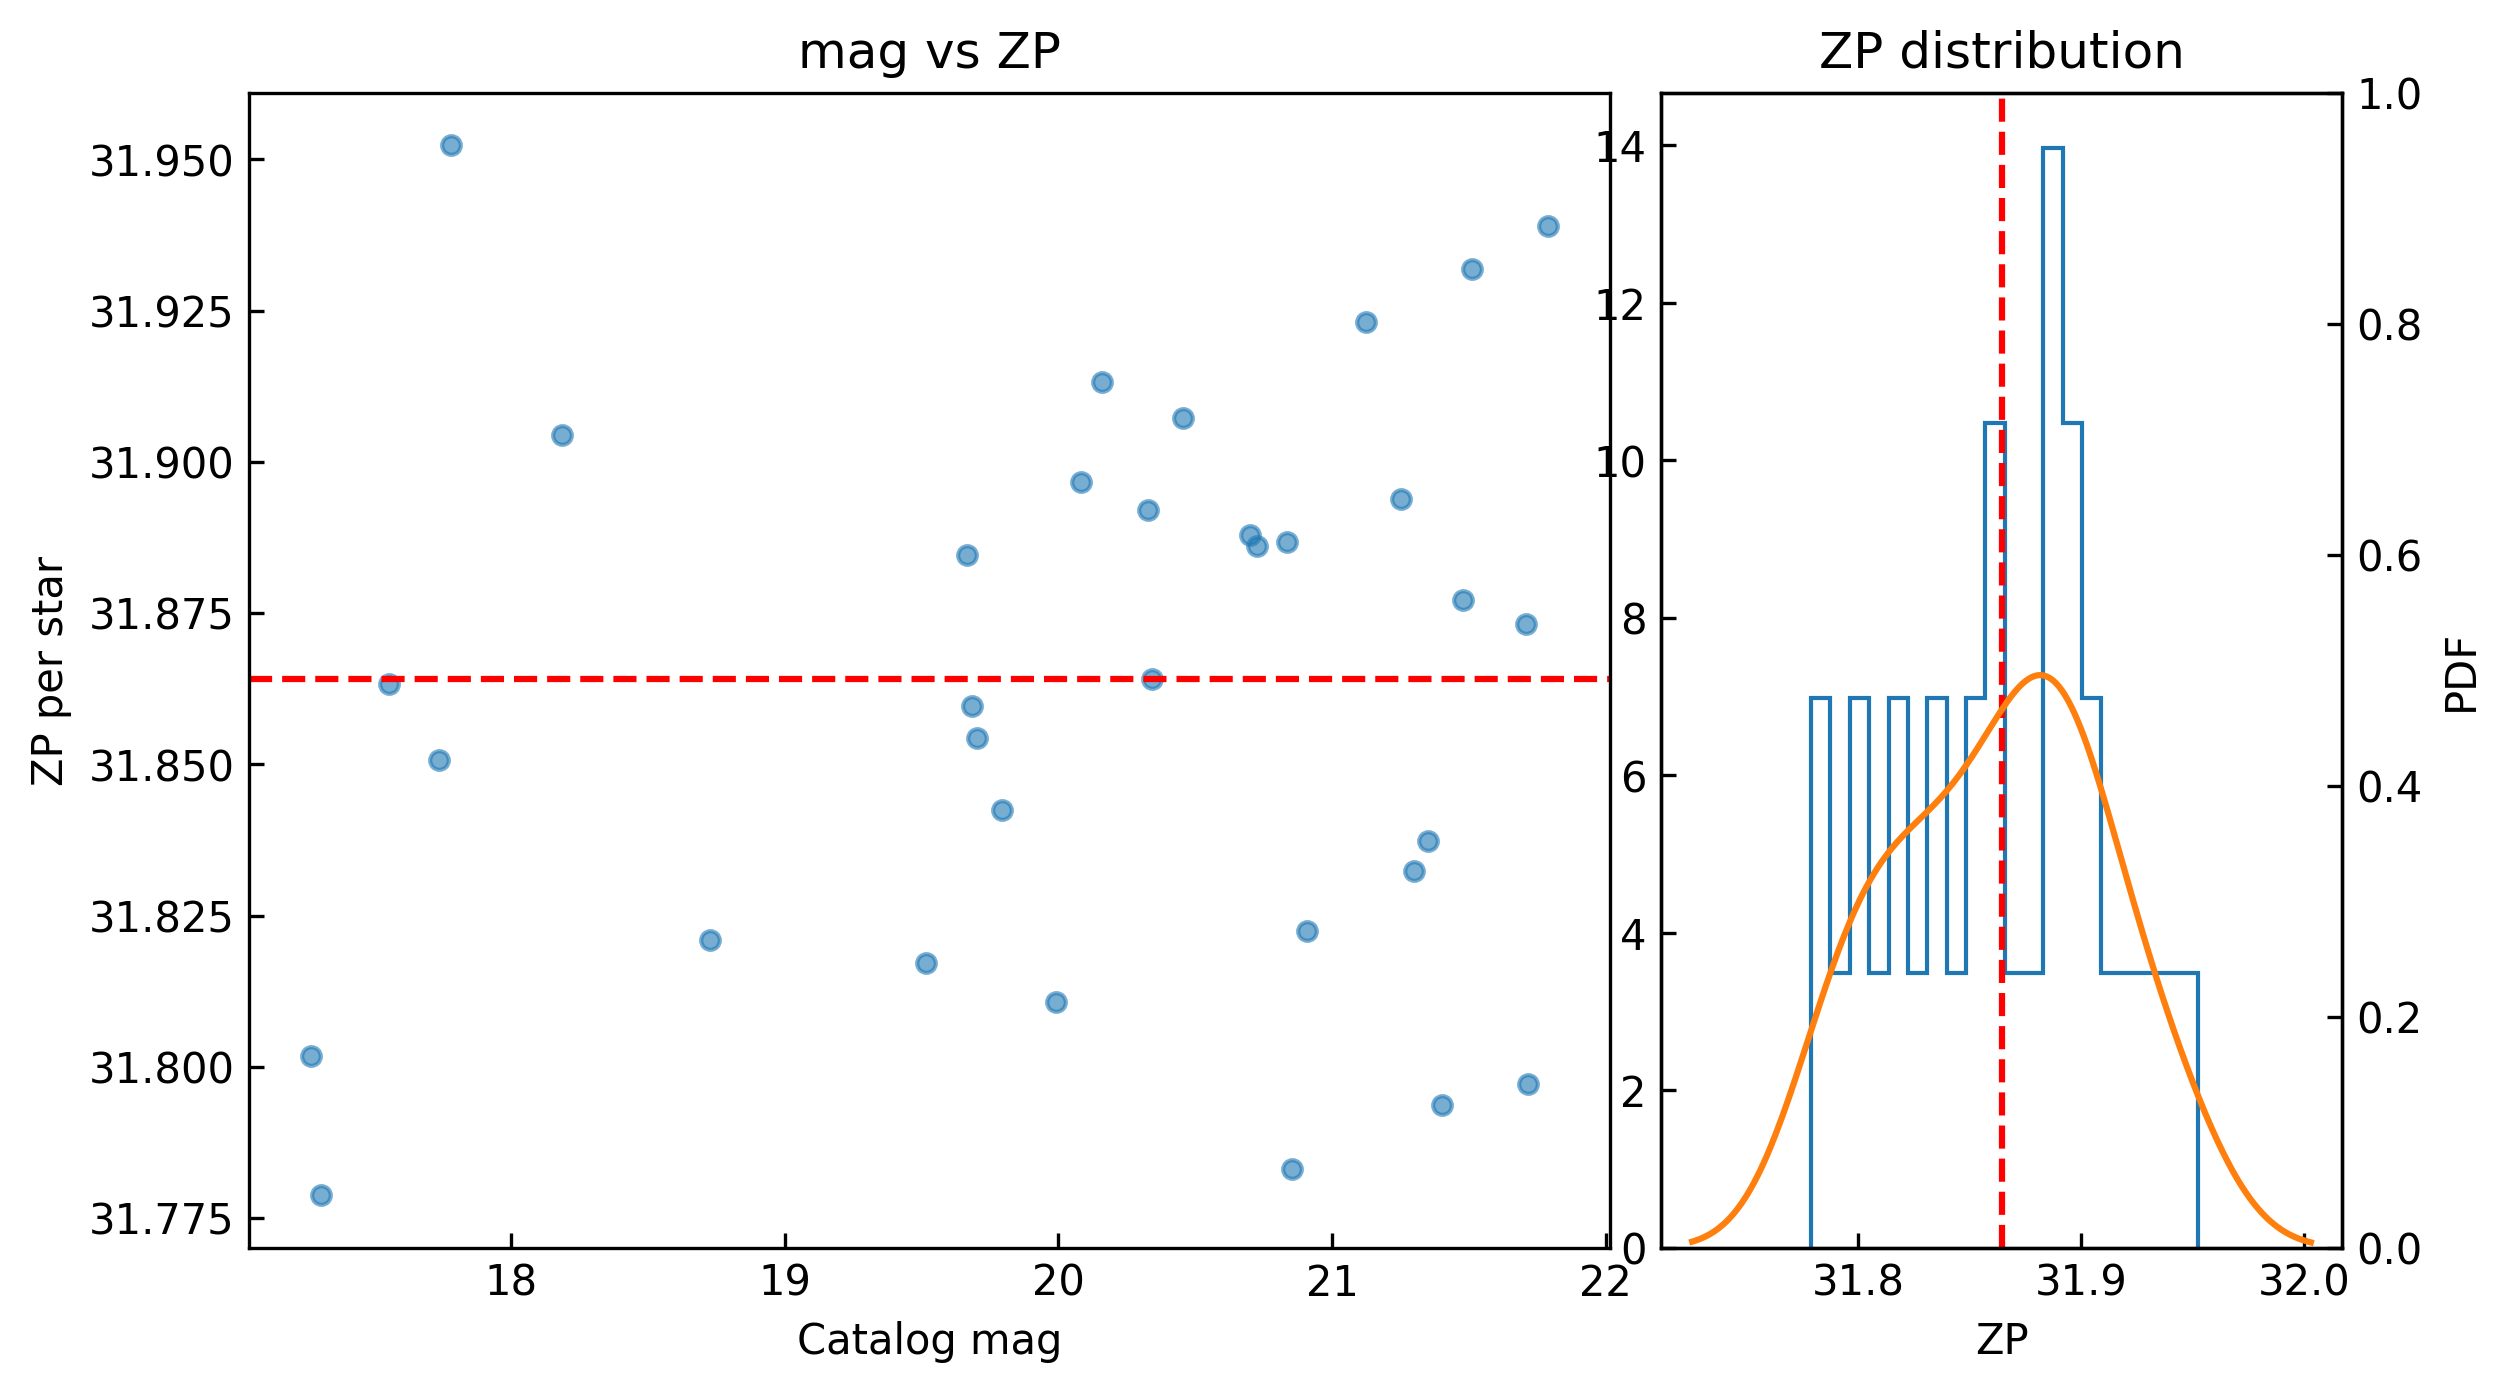

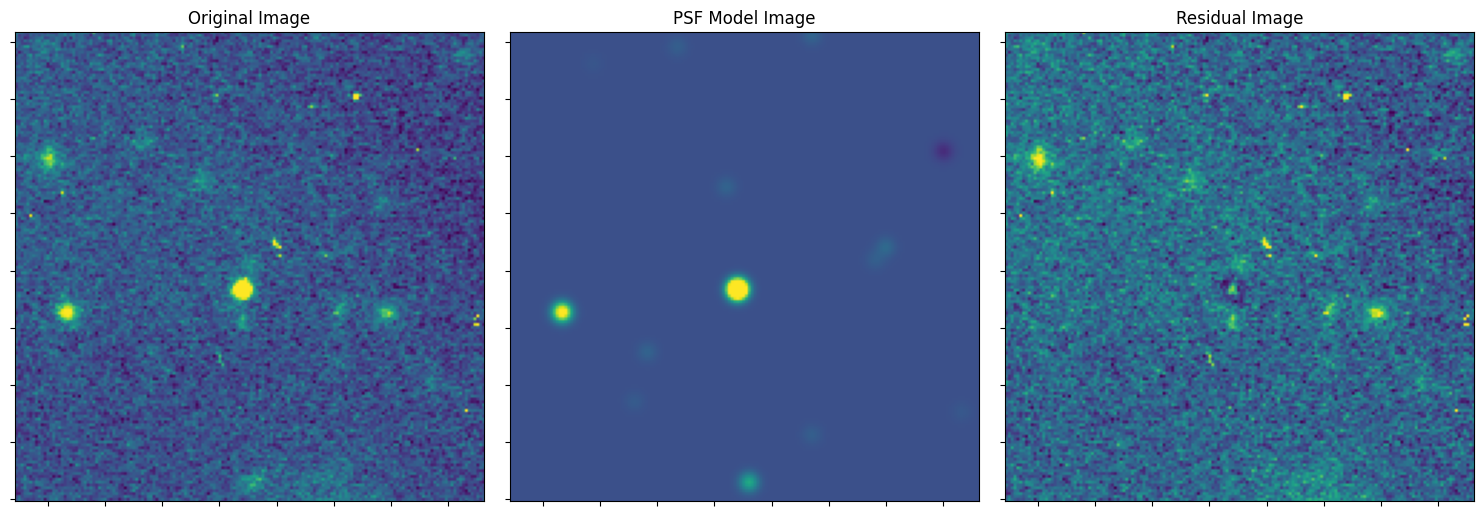

Aperture magnitude = 23.614 ± 0.160


id,xcenter,ycenter,aperture_sum,aperture_sum_err,total_bkg,aperture_sum_bkgsub
int64,float64,float64,float64,float64,float64,float64
1,330.4991014028434,361.40550684641585,2268.3198893423323,280.9164733772491,271.80622133275375,1996.5136680095786


In [5]:
phot.aperture_photometry(ra=ra,dec=dec,r_ap=1,r_in=15,r_out=25,cat_dir=cat_dir,sigma=3,fwhm=5.5,mag_col=band,fit_shape=(9,9))

In [8]:
target = SkyCoord(ra,dec,unit='deg')
cat = SkyCoord(phot.cat_df['RA'], phot.cat_df['DEC'], unit='deg')
idx, d2d, d3d = target.match_to_catalog_sky(cat)
phot.cat_df[['RA','DEC','i','i_err']].iloc[idx]

RA       149.901532
DEC       -3.320128
i         20.907600
i_err      0.045399
Name: 390, dtype: float64

## Upper Limits

In [21]:
fits_dir = '/Volumes/T7/Shared_Files/EP/Results/SBO/data/EP240506a_AT2024ofs/EP240506a_TRT/stack/TRT_2025-05-07_Rc.fits.fits'
fpath = '/Volumes/T7/Shared_Files/EP/Results/SBO/data/EP240506a_AT2024ofs/EP240506a_TRT/stack'

In [22]:
phot = Photometry()
phot.read_image(fits_dir)

Image and WCS loaded successfully.


In [23]:
zp_res = phot.compute_zeropoint(ps_dir='/Volumes/T7/Shared_Files/EP/Results/SBO/data/EP240506a_AT2024ofs/EP240506a_TRT/stack/ps.csv',path=fpath,mag_col='i',mag_cut=15,fwhm=7)

Estimated FWHM: 3.8+/-0.2 pixels
Zeropoint: 28.533 ± 0.332 mag (N=201)


In [32]:
phot.estimate_upperlimit(r=5)

23.182308910696744